Umar Saidu Zubairu (FE/23/48525350)

Nigeria Regional Electricity Demand

In [1]:
# Import Libraries 
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Data processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#IMPORT DATASET

df = pd.read_csv(r"C:\Users\USER\Downloads\nigeria_regional_electricity_demand_60000.csv")


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       60000 non-null  object 
 1   Region                     60000 non-null  object 
 2   Temperature_C              60000 non-null  float64
 3   Humidity_pct               60000 non-null  float64
 4   Population_Density         60000 non-null  int64  
 5   Industrial_Index           60000 non-null  float64
 6   Commercial_Index           60000 non-null  float64
 7   Residential_Index          60000 non-null  float64
 8   GDP_Index                  60000 non-null  float64
 9   Electricity_Price_NGN_kWh  60000 non-null  float64
 10  Holiday                    60000 non-null  int64  
 11  Weekend                    60000 non-null  int64  
 12  Rainfall_mm                60000 non-null  float64
 13  Peak_Hour                  60000 non-null  obj

MODEL 

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

Evaluation

In [4]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score
)

In [5]:
df.head()

,Date,Region,Temperature_C,Humidity_pct,Population_Density,Industrial_Index,Commercial_Index,Residential_Index,GDP_Index,Electricity_Price_NGN_kWh,Holiday,Weekend,Rainfall_mm,Peak_Hour,Month,Day_of_Week,Electricity_Demand_MWh
0,2022-01-01,North West,32.4,37.8,781,60.1,59.1,81.7,102.4,88.67,0,1,61.1,Afternoon,1,Saturday,912.36
1,2022-01-01,North East,25.9,43.8,845,57.6,75.1,87.6,57.6,93.77,0,1,30.3,Afternoon,1,Saturday,825.97
2,2022-01-01,North Central,25.2,78.0,675,62.5,51.4,64.5,57.5,88.65,0,1,108.9,Afternoon,1,Saturday,808.15
3,2022-01-01,South West,32.7,46.2,83,83.3,89.7,57.9,113.7,78.58,0,1,88.0,Afternoon,1,Saturday,1270.16
4,2022-01-01,South East,35.7,78.7,869,94.0,82.7,66.0,110.0,87.11,0,1,29.8,Afternoon,1,Saturday,1102.93


In [6]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

FEATURE TARGET

In [7]:
# Target

x = df.drop(columns=['Electricity_Demand_MWh', 'Date'])
y = df['Electricity_Demand_MWh']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

numeric_features = ['Temperature_C','Humidity_pct', 'Population_Density', 'Industrial_Index', 'Commercial_Index','Residential_Index','GDP_Index',
    'Electricity_Price_NGN_kWh','Rainfall_mm', 'Weekend']

categorical_features = ['Region', 'Peak_Hour']

SCALLING

In [8]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

MODELLING

In [9]:

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])


rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

EVALUATION AND TRAINING

In [10]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print('MAE', round(mae, 2))
    print('MSE', round(mse, 2))
    print('RMSE', round(rmse, 2))
    print('R² Score',  round(r2, 4))

    # Plot Actual vs Predicted
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )
    plt.xlabel("Actual Electricity Demand")
    plt.ylabel("Predicted Electricity Demand")
    plt.title("Actual vs Predicted")
    plt.show()

Linear Regression
MAE 19.96
MSE 538.59
RMSE 23.21
R² Score 0.9827


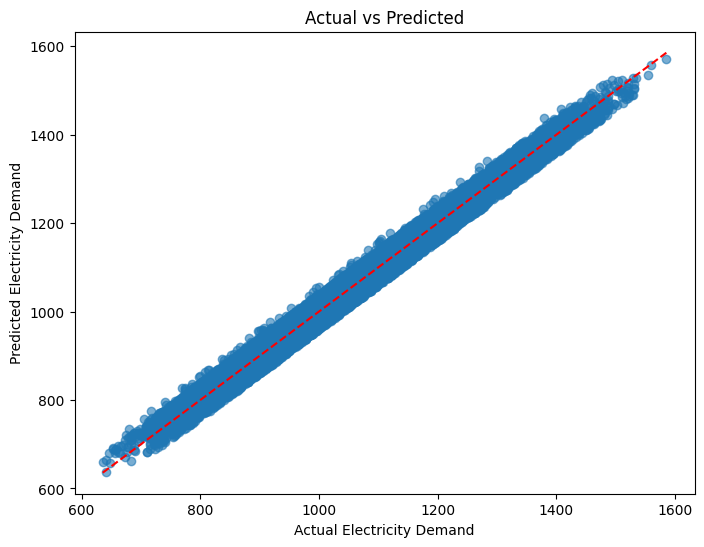


Random Forest Regressor
MAE 23.01
MSE 782.17
RMSE 27.97
R² Score 0.9749


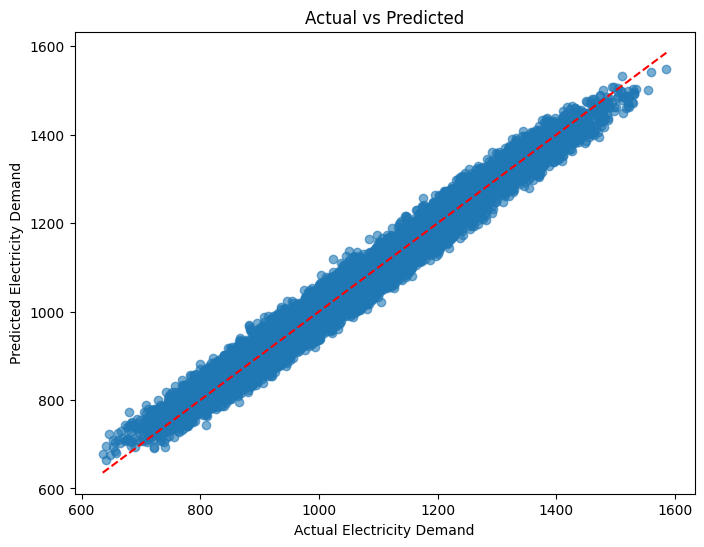

In [11]:
print("Linear Regression")
evaluate_model(lr_pipeline, x_train, x_test, y_train, y_test)

print("\nRandom Forest Regressor")
evaluate_model(rf_pipeline, x_train, x_test, y_train, y_test)

From the two models, it is clear that the  Linear Regression model outperformed the Random Forest Regressor, achieving lower prediction errors (MAE = 19.96, MSE = 538.59, RMSE = 23.21) and a higher R² score (0.9827). Therefore, Linear Regression was selected as the final model for regional electricity demand forecasting due to its superior predictive performance.

FINAL MODEL

In [12]:
final_model = lr_pipeline
joblib.dump(final_model, 'final_model.pkl')

['final_model.pkl']

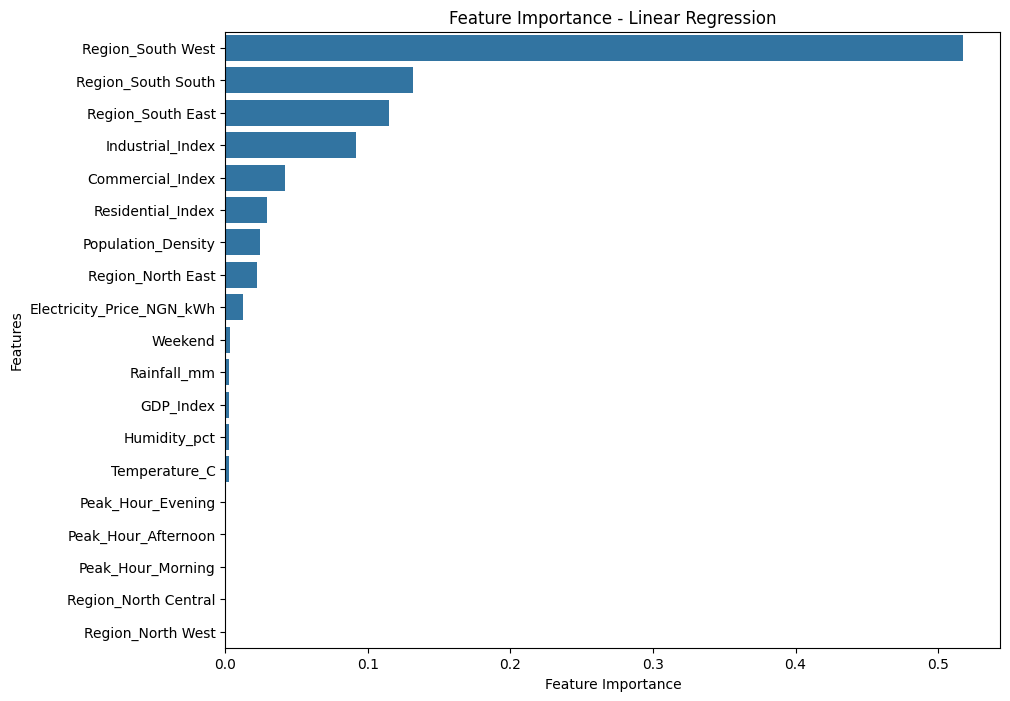

In [13]:
# feature importance
# Fit the final_model (Logistic Regression pipeline) to the training data
final_model = rf_pipeline

# Train the model
final_model.fit(x_train, y_train)

# Save the trained model
joblib.dump(final_model, 'final_model.pkl')

# Access the fitted preprocessor
preproc = final_model.named_steps['preprocessor']

# Numeric and categorical feature names
num_features = numeric_features
cat_features = categorical_features

# Get one-hot encoded categorical feature names
cat_encoder = preproc.named_transformers_['cat'].named_steps['onehot']
cat_features_names = cat_encoder.get_feature_names_out(cat_features)

# Combine all feature names
all_features_names = np.concatenate([num_features, cat_features_names])

# Get feature importances from the Random Forest model
importances = final_model.named_steps['model'].feature_importances_

# Create a feature importance Series
fi = pd.Series(importances, index=all_features_names).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x=fi.values, y=fi.index)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Linear Regression")
plt.show()

Generally, the final model shows that regional location is the most significant predictor of electricity demand in the Linear Regression model. The South West region has the greatest influence, followed by the South South and South East regions. Among the socioeconomic variables, the Industrial Index is the most influential, while the Commercial Index, Residential Index, and Population Density have moderate contributions. In contrast, Electricity Price, Temperature, Humidity, Rainfall, GDP Index, Weekend, and Peak Hour have relatively low influence, indicating that regional and socioeconomic factors are the primary drivers of regional electricity demand in the model.